In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import plotly.express as px

# 1. Chargement des données (Chemin pour dossier /notebooks)
path = '../data/insurance.csv'

if os.path.exists(path):

    dtype_dict = {'age': 'int8', 'sex': 'category', 'bmi': 'float16', 'children': 'int8', 'smoker': 'category', 'region': 'category', 'charges': 'float32'}

    df = pd.read_csv(path, low_memory=True, dtype=dtype_dict)
    df["smoker"] = df["smoker"].map({"yes": 1, "no": 0}).astype("bool")
    df["sex"] = df["sex"].map({"female": 1, "male": 0}).astype("bool")
    df.info()
    print(" Les données sont prêtes pour l'analyse de la Semaine 1.")
    print(f"Dataset : {df.shape[0]} lignes et {df.shape[1]} colonnes.")
else:
    print(f" Erreur : Je ne trouve pas le fichier au chemin : {path}")
    print("Vérifie bien que ton notebook est dans  le dossier 'notebooks'.")


df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       1338 non-null   int8    
 1   sex       1338 non-null   bool    
 2   bmi       1338 non-null   float16 
 3   children  1338 non-null   int8    
 4   smoker    1338 non-null   bool    
 5   region    1338 non-null   category
 6   charges   1338 non-null   float32 
dtypes: bool(2), category(1), float16(1), float32(1), int8(2)
memory usage: 14.7 KB
 Les données sont prêtes pour l'analyse de la Semaine 1.
Dataset : 1338 lignes et 7 colonnes.


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [2]:
# 3 Informations sur le DataFrame
# contrôle des doublons
df.duplicated().sum()

# Visualiser le doublon
df[df.duplicated()]

# Vérifier doublons sur les colonnes clés
df.duplicated(subset=["age","sex","bmi","children","smoker","region"]).sum()

# Voir toutes les lignes concernées
df[df.duplicated(keep=False)]

# Suppression des doublons
df = df.drop_duplicates()

# Vérification après suppression
df.duplicated().sum()





np.int64(0)

In [3]:
# Statistiques de base : mean, median, std, min, max, quartiles
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.656250,1.095737,13279.122070
std,14.044333,6.101562,1.205571,12110.359375
min,18.000000,15.960938,0.000000,1121.873901
25%,27.000000,26.296875,0.000000,4746.344238
50%,39.000000,30.406250,1.000000,9386.161133
75%,51.000000,34.687500,2.000000,16657.716797
max,64.000000,53.125000,5.000000,63770.429688


In [4]:
# Nombre de valeurs uniques par colonne
df.nunique()



age           47
sex            2
bmi          486
children       6
smoker         2
region         4
charges     1337
dtype: int64

In [5]:


region_counts = (
    df.groupby("region")
      .size()
      .reset_index(name="count")
)
print(region_counts)

region_charge_sum = (
    df.groupby("region")["charges"]
        .sum()
        .reset_index(name="total_charges")
)
print(region_charge_sum)

region_charge_mean = (
    df.groupby("region")["charges"]
    .mean()
    .reset_index(name="mean_charges")
)
print(region_charge_mean)

px.bar(
    region_counts,
    x="region",
    y="count",
    title="Number of insured persons per region "
).show()

px.bar(
    region_charge_sum,
    x="region",
    y="total_charges",
    title="total charges per region "
).show()

px.bar(
    region_charge_mean,
    x="region",
    y="mean_charges",
    title="mean of charges per region "
).show()








      region  count
0  northeast    324
1  northwest    324
2  southeast    364
3  southwest    325
      region  total_charges
0  northeast     4343668.50
1  northwest     4034072.50
2  southeast     5363690.00
3  southwest     4012754.75
      region  mean_charges
0  northeast  13406.383789
1  northwest  12450.840820
2  southeast  14735.412109
3  southwest  12346.937500


/tmp/ipykernel_10370/1955134148.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("region")
/tmp/ipykernel_10370/1955134148.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("region")["charges"]
/tmp/ipykernel_10370/1955134148.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("region")["charges"]


In [6]:
age_counts = (
    df.groupby("age")
      .size()
      .reset_index(name="count")
)
print(age_counts)

age_charge_sum = (
    df.groupby("age")["charges"]
    .sum()
    .reset_index(name="total_charge")
)
print(age_charge_sum)

age_charge_mean = (
    df.groupby("age")["charges"]
      .mean()
      .reset_index(name="mean_charge")
)
print(age_charge_mean)

age_charge_stats = df.groupby("age")["charges"].agg(
    mean_charge="mean",
    std_charge="std",
    total_charge="sum",
    count="count"
).reset_index()
print(age_charge_stats)

bins = [18, 25, 35, 45, 55, 65]
labels = ["18-24", "25-34", "35-44", "45-54", "55-64"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, right=False)





px.bar(
  age_counts,
  x="age",
  y="count", 
  title="Nombre d'assurés par âge"
  ).show()

px.bar(
  age_charge_sum,
  x="age", 
  y="total_charge",
  title="Charges totales par âge"
  ).show()

px.line(
  age_charge_mean,
  x="age",
  y="mean_charge", 
  title="Charge moyenne par âge"
  ).show()

px.box(
    df,
    x="age_group",
    y="charges",
    title="Distribution des charges par tranche d'âge"
).show()


    age  count
0    18     69
1    19     67
2    20     29
3    21     28
4    22     28
5    23     28
6    24     28
7    25     28
8    26     28
9    27     28
10   28     28
11   29     27
12   30     27
13   31     27
14   32     26
15   33     26
16   34     26
17   35     25
18   36     25
19   37     25
20   38     25
21   39     25
22   40     27
23   41     27
24   42     27
25   43     27
26   44     27
27   45     29
28   46     29
29   47     29
30   48     29
31   49     28
32   50     29
33   51     29
34   52     29
35   53     28
36   54     28
37   55     26
38   56     26
39   57     26
40   58     25
41   59     25
42   60     23
43   61     23
44   62     23
45   63     23
46   64     22
    age   total_charge
0    18  488949.000000
1    19  661218.250000
2    20  294631.218750
3    21  132453.000000
4    22  280362.125000
5    23  347754.968750
6    24  298144.437500
7    25  275474.218750
8    26  171747.109375
9    27  341171.656250
10   28  253937.250000
11  

BMI Analyse

In [7]:
df["bmi"] = df["bmi"].astype("float64")

df["bmi_category"] = pd.cut(
    df["bmi"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

bmi_counts = (
    df.groupby("bmi_category", observed=True)
      .size()
      .reset_index(name="count")
)
print(bmi_counts)

bmi_charge_sum = (
    df.groupby("bmi_category", observed=True)["charges"]
      .sum()
      .reset_index(name="total_charges")
)
print(bmi_charge_sum)

bmi_charge_mean = (
    df.groupby("bmi_category", observed=True)["charges"]
      .mean()
      .reset_index(name="mean_charges")
)
print(bmi_charge_mean)


px.bar(
    bmi_counts,
    x="bmi_category",
    y="count",
    title="Number of insured persons per BMI category"
).show()

px.bar(
    bmi_charge_sum,
    x="bmi_category",
    y="total_charges",
    title="Total charges per BMI category"
).show()

px.bar(
    bmi_charge_mean,
    x="bmi_category",
    y="mean_charges",
    title="Mean charges per BMI category"
).show()

  bmi_category  count
0  Underweight     21
1       Normal    226
2   Overweight    386
3        Obese    704
  bmi_category  total_charges
0  Underweight   1.818100e+05
1       Normal   2.358410e+06
2   Overweight   4.245152e+06
3        Obese   1.096881e+07
  bmi_category  mean_charges
0  Underweight   8657.620117
1       Normal  10435.440430
2   Overweight  10997.804688
3        Obese  15580.700195


In [8]:
bmi_mean = df["bmi"].mean()
bmi_median = df["bmi"].median()
bmi_std = df["bmi"].std()

print("Moyenne BMI :", bmi_mean)
print("Médiane BMI :", bmi_median)
print("Écart-type BMI :", bmi_std)

Moyenne BMI : 30.663466482797308
Médiane BMI : 30.40625
Écart-type BMI : 6.100637508980295


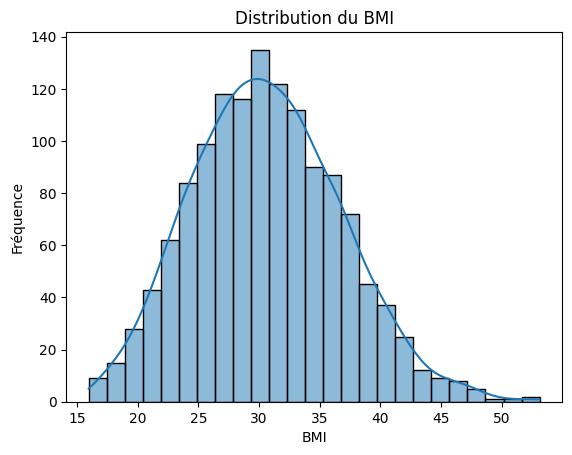

In [9]:
# BMI distribution en valeur absolue

sns.histplot(df["bmi"], kde=True)
plt.title("Distribution du BMI")
plt.xlabel("BMI")
plt.ylabel("Fréquence")
plt.show()

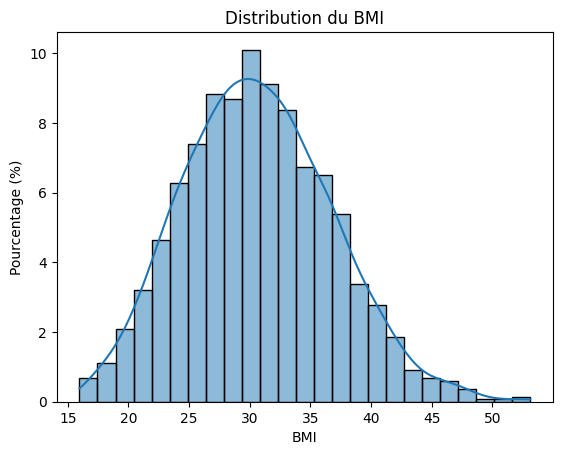

In [10]:
# distribution des BMI en %

sns.histplot(df["bmi"], stat="percent", kde=True)
plt.title("Distribution du BMI")
plt.xlabel("BMI")
plt.ylabel("Pourcentage (%)")
plt.show()

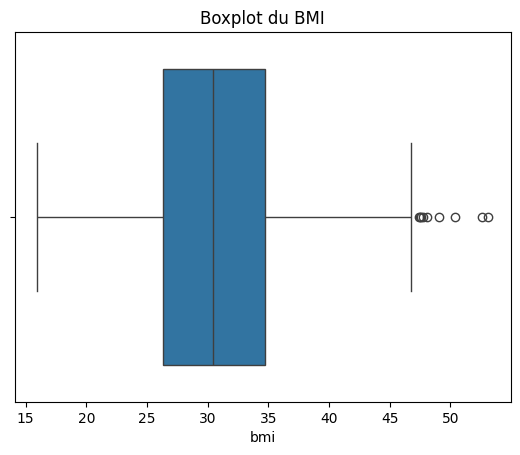

In [11]:
sns.boxplot(x=df["bmi"])
plt.title("Boxplot du BMI")
plt.show()


Smokers Analyse

In [12]:
df["smoker_label"] = df["smoker"].map({True: "Smoker", False: "No-smoker"})

smoker_counts = (
    df.groupby("smoker_label", observed=True)
      .size()
      .reset_index(name="count")
)
print(smoker_counts)

smoker_charge_sum = (
    df.groupby("smoker_label", observed=True)["charges"]
      .sum()
      .reset_index(name="total_charges")
)
print(smoker_charge_sum)

smoker_charge_mean = (
    df.groupby("smoker_label", observed=True)["charges"]
      .mean()
      .reset_index(name="mean_charges")
)
print(smoker_charge_mean)

px.bar(
    smoker_counts,
    x="smoker_label",
    y="count",
    title="Number of insured persons by smoking status"
).show()

px.bar(
    smoker_charge_sum,
    x="smoker_label",
    y="total_charges",
    title="Total charges by smoking status"
).show()

px.bar(
    smoker_charge_mean,
    x="smoker_label",
    y="mean_charges",
    title="Mean charges by smoking status"
).show()

  smoker_label  count
0    No-smoker   1063
1       Smoker    274
  smoker_label  total_charges
0    No-smoker      8972422.0
1       Smoker      8781764.0
  smoker_label  mean_charges
0    No-smoker   8440.660156
1       Smoker  32050.234375


In [13]:
# en %
df["smoker"].value_counts(normalize=True) * 100

smoker
False    79.506358
True     20.493642
Name: proportion, dtype: float64

In [14]:
# Mediane et mean des charges pr fumeurs ou non

df.groupby("smoker")["charges"].agg(["count", "mean", "median"])

,count,mean,median
smoker,,,
False,1063,8440.660156,7345.726562
True,274,32050.234375,34456.347656


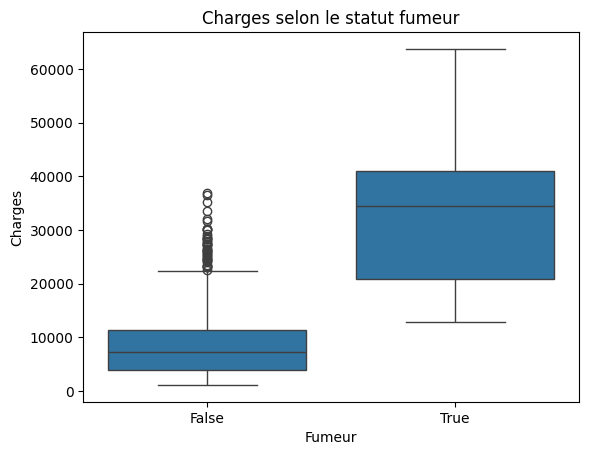

In [15]:
sns.boxplot(data=df, x="smoker", y="charges")
plt.title("Charges selon le statut fumeur")
plt.xlabel("Fumeur")
plt.ylabel("Charges")
plt.show()

Fumeurs et Bmi

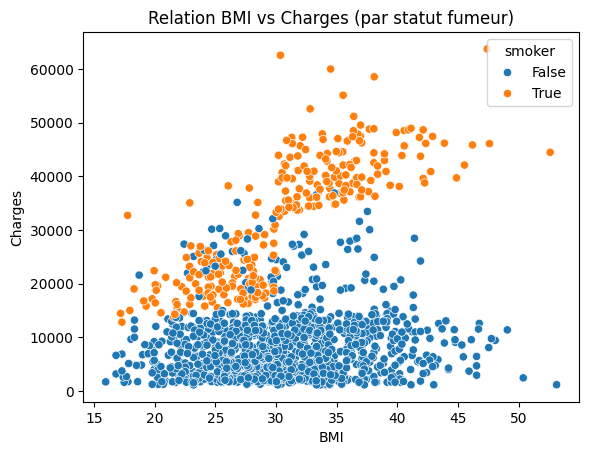

In [16]:
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker")
plt.title("Relation BMI vs Charges (par statut fumeur)")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

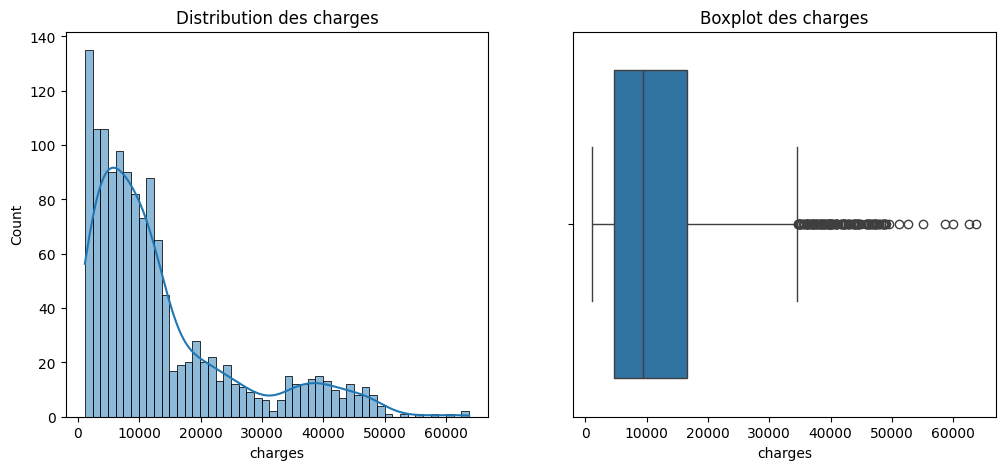

In [17]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['charges'], bins=50, kde=True)
plt.title("Distribution des charges")

plt.subplot(1,2,2)
sns.boxplot(x=df['charges'])
plt.title("Boxplot des charges")

plt.show()


In [18]:
quantiles = df['charges'].quantile([0.90, 0.95, 0.99])
print(quantiles)

total_charges = df['charges'].sum()

for q in [0.95, 0.99]:
    threshold = df['charges'].quantile(q)
    part = df[df['charges'] >= threshold]['charges'].sum() / total_charges
    print(f"Part des charges au-dessus du quantile {q*100:.0f}% : {part:.2%}")


0.90    34832.739844
0.95    41210.048438
0.99    48537.797500
Name: charges, dtype: float64
Part des charges au-dessus du quantile 95% : 17.58%
Part des charges au-dessus du quantile 99% : 4.20%


5% des assurer 17.58% des charges totales

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Optionnel : style seaborn
sns.set(style="whitegrid")


In [20]:
# Chemin vers ton dataset
path = '../data/insurance.csv'

dtype_dict = {
    'age': 'int32', 'sex': 'category', 'bmi': 'float32',
    'children': 'int32', 'smoker': 'category', 'region': 'object',
    'charges': 'float64'
}

df = pd.read_csv(path, dtype=dtype_dict)


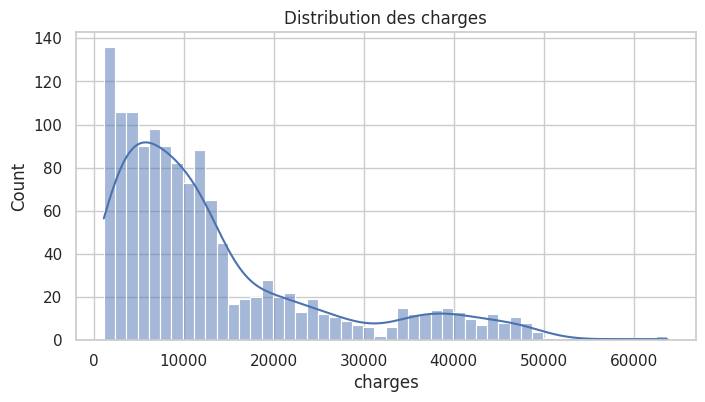

In [21]:
# 1️ Histogramme des charges
# Montre la distribution des charges d’assurance.

plt.figure(figsize=(8,4))
sns.histplot(df['charges'], bins=50, kde=True)
plt.title("Distribution des charges")
plt.show()









## 1️Histogramme des charges


**Observation**  
- La majorité des charges se situe autour de **10 000 $**.  
- Quelques **outliers très élevés** dépassant **50 000 $**.  
- Distribution **asymétrique à droite**.

**Conclusion**  
Certaines valeurs extrêmes peuvent **influencer un modèle**.  
Une **transformation logarithmique** est à envisager pour **réduire l’impact des outliers**.


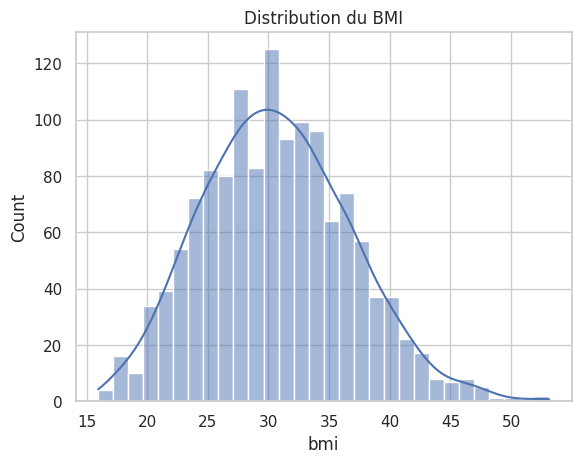

In [22]:

# 2️ Histogramme du BMI
# Montre la distribution de l’indice de masse corporelle (BMI).

sns.histplot(df['bmi'], bins=30, kde=True)
plt.title("Distribution du BMI")
plt.show()


## 2️ Histogramme du BMI

**Observation**  
- La plupart des assurés ont un **BMI entre 20 et 35**.  
- Quelques **valeurs extrêmes plausibles**.

**Conclusion**  
Les valeurs sont **cohérentes** et ne nécessitent pas de nettoyage,  
mais il est important de **noter la présence de quelques outliers**.


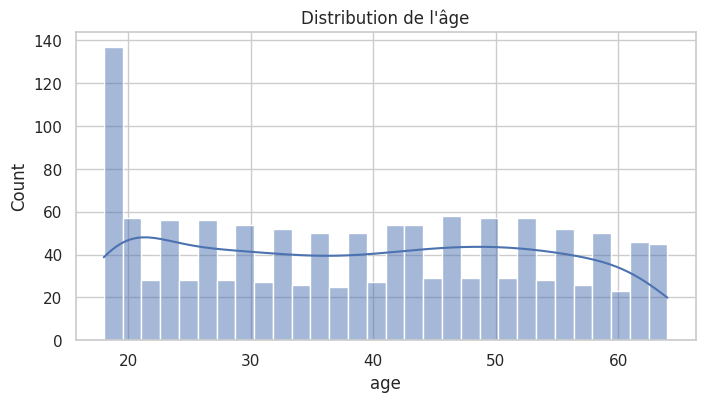

In [23]:
# 3️ Histogramme de l’âge
# Montre la répartition des âges.
plt.figure(figsize=(8,4))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Distribution de l'âge")
plt.show()

**Observation**  
- Âge compris entre **18 et 64 ans**.  
- Distribution **assez normale**.

**Conclusion**  
Variable **propre et cohérente**, sans **valeurs aberrantes**.


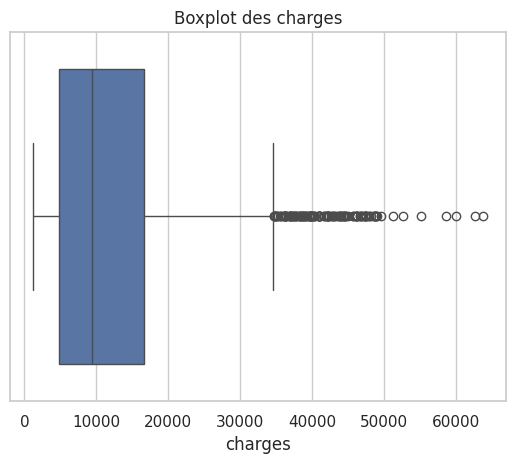

In [24]:
# 1️Boxplot des charges
# Visualise la médiane, les quartiles et les outliers pour les charges.


sns.boxplot(x=df['charges'])
plt.title("Boxplot des charges")
plt.show()










## 1️Boxplot des charges

**Objectif**  
Visualiser la **médiane**, les **quartiles** et les **outliers** des charges.

**Observation**  
- La majorité des charges est concentrée autour de **10 000 $**.  
- Présence de **plusieurs outliers très élevés**, dépassant **50 000 $**.

**Conclusion**  
Ces valeurs extrêmes peuvent **fortement influencer un modèle linéaire**.  
Une **transformation logarithmique** des charges peut être envisagée afin de **réduire l’impact des outliers** et améliorer la stabilité du modèle.


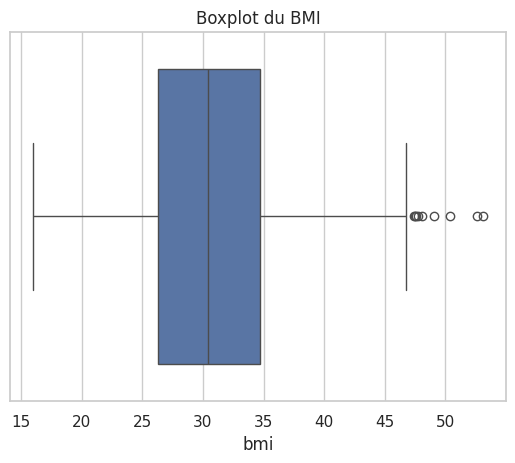

In [25]:
#2️ Boxplot du BMI
# Montre la distribution du BMI avec médiane, quartiles et outliers.

sns.boxplot(x=df['bmi'])
plt.title("Boxplot du BMI")
plt.show()

## 2️ Boxplot du BMI

**Objectif**  
Montrer la distribution du **BMI** avec médiane, quartiles et outliers.

**Observation**  
- La plupart des individus ont un **BMI entre 20 et 35**.  
- Quelques **valeurs extrêmes au-delà de 50**.

**Conclusion**  
Les valeurs sont **plausibles**, mais les **outliers doivent être pris en compte** pour l’analyse et éventuellement pour le **scaling**.


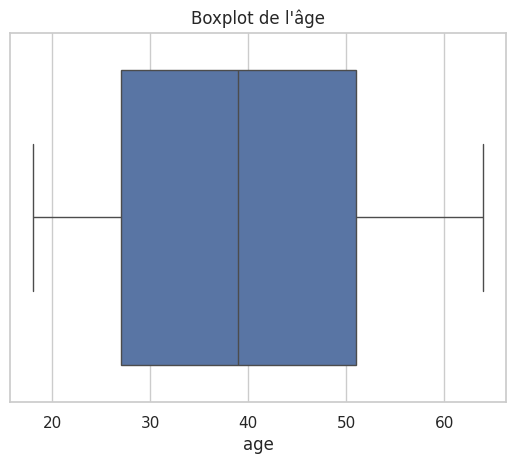

In [26]:
# 3️ Boxplot de l'âge
# Visualise la répartition de l'âge.


sns.boxplot(x=df['age'])
plt.title("Boxplot de l'âge")
plt.show()


## 3️ Boxplot de l’âge

**Objectif**  
Visualiser la répartition de l’âge.

**Observation**  
- Âge compris entre **18 et 64 ans**.  
- Distribution **plutôt normale**, avec **peu d’outliers**.

**Conclusion**  
Variable **propre et cohérente**, ne nécessitant **pas de nettoyage particulier**.


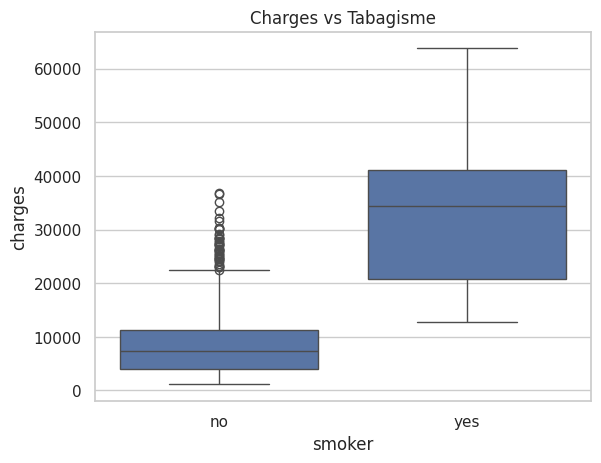

In [27]:
# 4️ Boxplot Charges vs Tabagisme
# Compare les charges entre fumeurs et non-fumeurs.

sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Charges vs Tabagisme")
plt.show()


## 4️Boxplot Charges vs Tabagisme

**Objectif**  
Comparer les charges entre **fumeurs** et **non-fumeurs**.

**Observation**  
- Les **fumeurs** ont des charges **beaucoup plus élevées** que les non-fumeurs.  
- Présence d’**outliers encore plus extrêmes** chez les fumeurs.

**Conclusion**  
Le **tabagisme** est un **facteur clé** pour expliquer les charges.  
Cette variable doit **absolument être incluse dans le modèle**.

```python
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Charges vs Tabagisme")
plt.show()


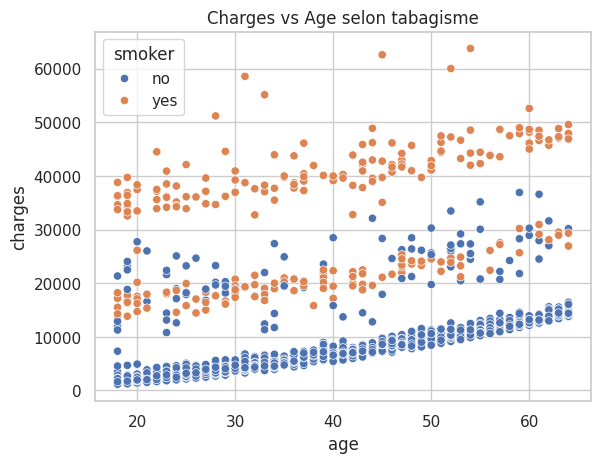

In [28]:
# 1️Scatterplot Charges vs Age
# Visualise la relation entre l'âge et les charges, en différenciant fumeurs et non-fumeurs.


sns.scatterplot(x='age', y='charges', hue='smoker', data=df)
plt.title("Charges vs Age selon tabagisme")
plt.show()





## 1️ Scatterplot Charges vs Âge

**Objectif**  
Visualiser la relation entre l’âge et les charges, en distinguant les **fumeurs** et les **non-fumeurs**.

**Observation**  
- Pour les **non-fumeurs**, les charges restent relativement **faibles** et varient peu avec l’âge.  
- Pour les **fumeurs**, les charges **augmentent avec l’âge** et présentent des **outliers très élevés**.

**Conclusion**  
L’effet de l’âge sur les charges dépend fortement du **tabagisme**.  
L’interaction **âge × smoker** est donc **essentielle à intégrer dans le modèle** afin d’améliorer la qualité des prédictions.


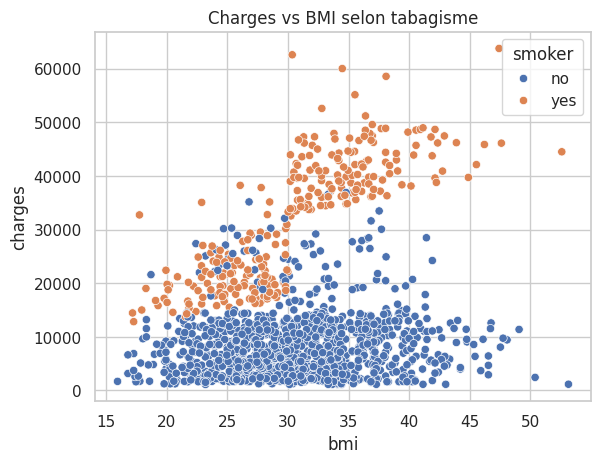

In [29]:
#2️ Scatterplot Charges vs BMI
# Visualise la relation entre le BMI et les charges, en différenciant fumeurs et non-fumeurs.


sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.title("Charges vs BMI selon tabagisme")
plt.show()


## 2️ Scatterplot Charges vs BMI

**Objectif**  
Visualiser la relation entre le **BMI** et les charges, en distinguant les **fumeurs** et les **non-fumeurs**.

**Observation**  
- Pour les **non-fumeurs**, les charges sont **modérées** avec une **légère augmentation** lorsque le BMI augmente.  
- Pour les **fumeurs**, les charges **augmentent beaucoup plus fortement** avec le BMI, avec la présence de **plusieurs outliers extrêmes**.

**Conclusion**  
Le **BMI** a un impact principalement chez les **fumeurs**.  
L’interaction **BMI × smoker** constitue donc un **facteur clé** pour la prédiction des charges.


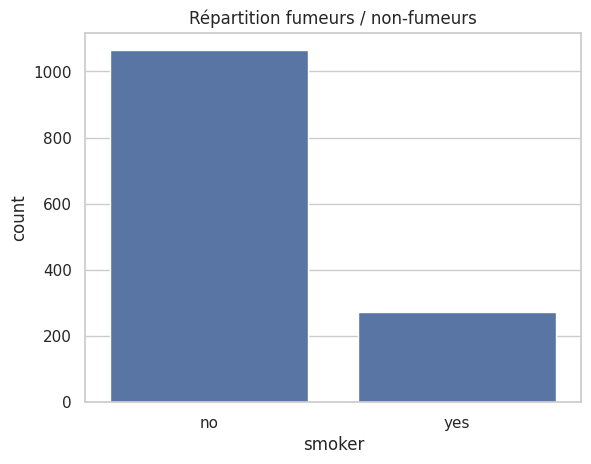

In [30]:
# 1️ Répartition fumeurs / non-fumeurs
# Visualise le nombre d'individus fumeurs et non-fumeurs.

sns.countplot(x='smoker', data=df)
plt.title("Répartition fumeurs / non-fumeurs")
plt.show()





## 1️ Répartition fumeurs / non-fumeurs

**Objectif**  
Visualiser la répartition des individus fumeurs et non-fumeurs dans le jeu de données.

**Observation**  
- Environ **80 %** des assurés sont **non-fumeurs**.  
- Environ **20 %** des assurés sont **fumeurs**.

**Conclusion**  
La variable **`smoker`** est **déséquilibrée**, mais elle est **très déterminante** pour expliquer le montant des charges.  
Elle devra impérativement être **incluse dans le modèle**, car elle est susceptible d’avoir une **influence forte sur la prédiction**.


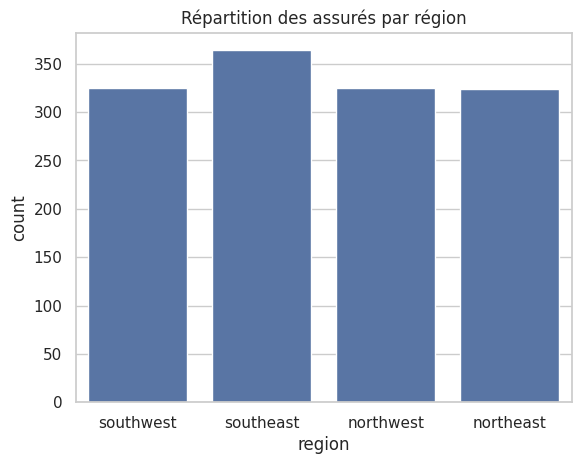

In [31]:
# 2️ Répartition des assurés par région
# Visualise le nombre d'individus dans chaque région.


sns.countplot(x='region', data=df)
plt.title("Répartition des assurés par région")
plt.show()


## 2️ Répartition des assurés par région

**Objectif**  
Visualiser le nombre d’individus dans chaque région.

**Observation**  
- Les quatre régions (**northeast**, **northwest**, **southeast**, **southwest**) sont **relativement équilibrées**.  
- Chaque région compte environ **320 à 360 assurés**.

**Conclusion**  
Il existe **peu de biais lié à la région**.  
Cette variable peut être utilisée pour des **analyses groupées** ou intégrée comme **variable catégorielle** dans le modèle.


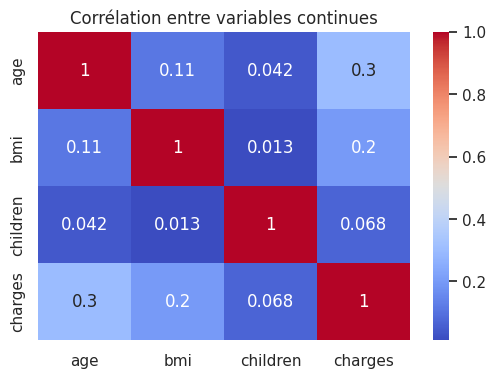

In [32]:
# Heatmap : Corrélation entre variables continues
# Visualise les corrélations entre âge, BMI, nombre d'enfants et charges.
plt.figure(figsize=(6,4))
sns.heatmap(df[['age','bmi','children','charges']].corr(), annot=True, cmap='coolwarm')
plt.title("Corrélation entre variables continues")
plt.show()



###  Heatmap – Corrélation entre variables continues

Cette visualisation met en évidence les corrélations entre les variables numériques :
**âge**, **BMI**, **nombre d’enfants** et **charges**.

#### Observations
- Les **charges** corrèlent positivement avec :
  - l’**âge** (corrélation ≈ 0.3),
  - le **BMI** (corrélation ≈ 0.2–0.3).
- La corrélation entre les **charges** et le **nombre d’enfants** est très faible
  (corrélation ≈ 0.1), indiquant un impact limité.
- Les corrélations entre les autres variables continues restent faibles à modérées.

#### Conclusion
- Les variables continues les plus importantes pour expliquer les **charges**
  sont l’**âge** et le **BMI**.
- La variable **children** a un effet marginal et pourrait être moins influente
  dans le modèle.
- Cette heatmap permet d’identifier les variables prioritaires pour la phase de
  modélisation et d’orienter la sélection de features.


##  Synthèse finale – Analyse exploratoire (Semaine 1)

### Qualité et structure des données
- Le jeu de données est globalement propre.
- Aucune valeur manquante critique n’a été détectée.
- Un nombre très limité de doublons a été identifié et traité.
- Les types de variables sont cohérents :
  - **Numériques** : `age`, `bmi`, `children`, `charges`
  - **Catégorielles** : `sex`, `smoker`, `region`

---

### Analyse des distributions

**Charges**
- Distribution fortement asymétrique à droite avec plusieurs valeurs extrêmes (> 50 000$).
- Ces outliers peuvent fortement influencer un modèle linéaire.
- Une transformation logarithmique des charges est pertinente pour la modélisation.

**BMI**
- La majorité des valeurs est comprise entre 20 et 35.
- Quelques valeurs extrêmes existent mais restent plausibles.
- Variable exploitable telle quelle, en conservant les outliers à l’esprit.

**Âge**
- Distribution cohérente entre 18 et 64 ans.
- Pas de valeurs aberrantes significatives.
- Variable stable et bien adaptée à la modélisation.

---

### Relations entre variables
- Le **tabagisme** est le facteur le plus discriminant :
  - Les fumeurs ont des charges nettement plus élevées que les non-fumeurs.
- L’**âge** et le **BMI** ont un impact positif sur les charges,
  - impact beaucoup plus marqué chez les fumeurs.
- Le **nombre d’enfants** présente une corrélation faible avec les charges.
- Les **régions** sont relativement équilibrées et expliquent peu la variance des charges.

---

### Enseignements pour la suite du projet
- Variables clés pour la modélisation :
  - `smoker`, `age`, `bmi`
- Présence d’outliers et forte asymétrie des charges :
  - nécessité d’un **scaling**
  - justification d’une **transformation logarithmique**
- Ces observations justifient la mise en place d’un **pipeline de préparation des données**
  avant la phase de modélisation (Semaine 2 : baseline et évaluation).


In [33]:
from ydata_profiling import ProfileReport

# Création du rapport
profile = ProfileReport(
    df,
    title="Insurance Dataset – EDA Report",
    explorative=True
)

# Affichage du rapport
profile



Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 7/7 [00:00<00:00, 46976.20it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]